# Iowa Liquor Sales Analysis  
### Market Structure, Chain Performance, and Store Productivity

This analysis explores the structure of the Iowa liquor sales market using transaction-level data modeled in Snowflake and dbt.

The goal is to understand:
- how sales are distributed across major chains vs the long tail  
- which chains dominate total revenue  
- how store-level productivity varies across different retail formats  

In [2]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

user = os.getenv("DBT_USER")
password = os.getenv("DBT_PASSWORD")
account = os.getenv("DBT_ACCOUNT")
warehouse = os.getenv("DBT_WAREHOUSE")
database = os.getenv("DBT_DATABASE")
schema = os.getenv("DBT_DEV_SCHEMA")

print(user, account, database, schema)

engine = create_engine(
    f"snowflake://{user}:{password}@{account}/{database}/{schema}?warehouse={warehouse}"
)

joelam STHKDLC-NRB37885 planning_os dev


In [3]:
import pandas as pd

pd.read_sql("select current_version()", engine)

,CURRENT_VERSION()
0,10.9.2


## Data Overview

The analysis is based on curated data models built using dbt:

- `fct_store_daily_sales` → aggregated sales at the store/day level  
- `dim_store` → store attributes including derived chain classifications  

The data has been cleaned, standardized, and enriched to support analysis of:
- chain-level performance  
- store-level aggregation  
- derived business groupings (Top Chains vs Long Tail)

In [67]:
query = """
select
    f.order_date,
    f.store_number,
    f.total_sales_dollars,
    f.total_estimated_gross_profit,
    f.total_bottles_sold,
    s.store_name,
    s.chain,
    s.city,
    s.county
from fct_store_daily_sales f
left join dim_store s
    on f.store_number = s.store_number
"""

df = pd.read_sql(query, engine)

df.head()

,order_date,store_number,total_sales_dollars,total_estimated_gross_profit,total_bottles_sold,store_name,chain,city,county
0,2021-11-03,2647,11534.12,3852.08,697,HY-VEE #7 / CEDAR RAPIDS,HY-VEE,CEDAR RAPIDS,LINN
1,2021-11-01,2647,17373.67,5767.36,1048,HY-VEE #7 / CEDAR RAPIDS,HY-VEE,CEDAR RAPIDS,LINN
2,2021-11-01,6076,9305.35,3102.85,884,SHOP N SAVE NEWTON,INDEPENDENT,NEWTON,JASPER
3,2021-11-01,2709,2198.75,733.15,185,HY-VEE FAST AND FRESH - DUBUQUE,HY-VEE,DUBUQUE,DUBUQUE
4,2021-11-01,6000,1241.22,413.94,171,PORTERS CONVENIENCE 66 / CLINTON,INDEPENDENT,CLINTON,CLINTON


In [70]:
df.shape

(1399, 9)

In [71]:
df.describe()

,total_sales_dollars,total_estimated_gross_profit,total_bottles_sold
count,1399.000000,1399.000000,1399.000000
mean,6261.384889,2087.374882,427.966405
std,11800.575926,3930.613545,698.887939
min,9.000000,3.000000,1.000000
25%,1638.450000,546.275000,133.500000
50%,2749.470000,914.580000,230.000000
75%,5518.985000,1840.220000,444.500000
max,176039.220000,58661.040000,9979.000000


In [75]:
chain_sales = (
    df.groupby("chain")["total_sales_dollars"]
    .sum()
    .sort_values(ascending=False)
)

# Keep top 5, group rest
top_n = 5
top_chains = chain_sales.head(top_n)

others = chain_sales.iloc[top_n:].sum()

final = top_chains.copy()
final["OTHER"] = others

## Methodology

To analyze market structure, stores were grouped into:

- **Top 5 Chains** → based on total sales  
- **Other (Long Tail)** → includes:
  - independent stores  
  - smaller regional chains  

This grouping enables a clearer view of:
- market concentration  
- fragmentation across smaller players  

Additionally, store productivity was measured using:

- **Average Sales per Store = Total Sales / Distinct Store Count**

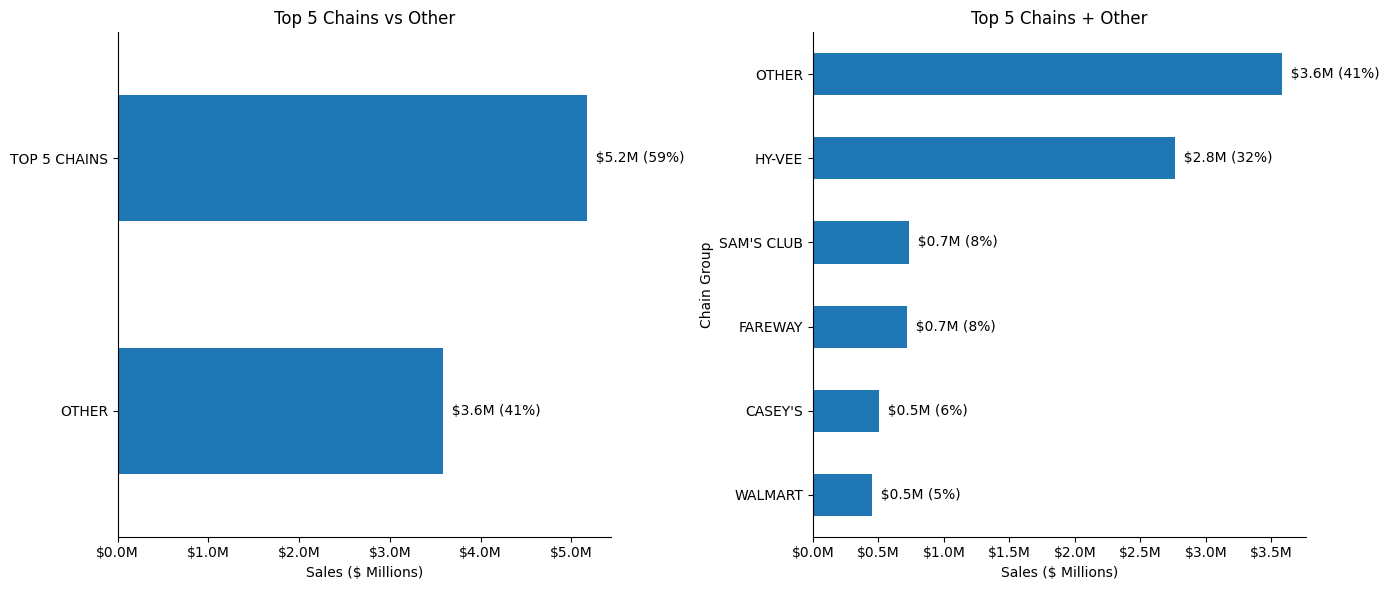

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# =========================
# Data prep
# =========================

chain_sales = (
    df.groupby("chain")["total_sales_dollars"]
    .sum()
)

# Separate independent → fold into OTHER
independent_sales = chain_sales.get("INDEPENDENT", 0)
chain_sales_clean = chain_sales.drop("INDEPENDENT", errors="ignore")

# Top 5 chains
top_5 = chain_sales_clean.sort_values(ascending=False).head(5)

# OTHER = remaining + independent
other_sales = chain_sales_clean.drop(top_5.index).sum() + independent_sales

# =========================
# Build views
# =========================

# Left panel
aggregate_view = pd.Series(
    {
        "OTHER": other_sales,
        "TOP 5 CHAINS": top_5.sum()
    }
).sort_values()

# Right panel
full_view = top_5.copy()
full_view["OTHER"] = other_sales
full_view = full_view.sort_values()

# Total for % calc
total_market = aggregate_view.sum()

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -------- LEFT PANEL --------
aggregate_view.plot(kind="barh", ax=axes[0])

axes[0].set_title("Top 5 Chains vs Other")
axes[0].set_xlabel("Sales ($ Millions)")
axes[0].set_ylabel("")

axes[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

# Add labels ($ + %)
for i, v in enumerate(aggregate_view):
    pct = v / total_market
    axes[0].text(
        v,
        i,
        f"  ${v/1_000_000:.1f}M ({pct:.0%})",
        va="center"
    )

# -------- RIGHT PANEL --------
full_view.plot(kind="barh", ax=axes[1])

axes[1].set_title("Top 5 Chains + Other")
axes[1].set_xlabel("Sales ($ Millions)")
axes[1].set_ylabel("Chain Group")

axes[1].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

# Add labels ($ + %)
for i, v in enumerate(full_view):
    pct = v / total_market
    axes[1].text(
        v,
        i,
        f"  ${v/1_000_000:.1f}M ({pct:.0%})",
        va="center"
    )

plt.tight_layout()
plt.show()

## Market Structure: Top Chains vs Long Tail

The chart below compares:
- aggregate performance of the top 5 chains vs the rest of the market  
- individual performance of the top 5 chains alongside the long tail  

## Key Insights: Chain vs Long Tail Performance

**1. Market is concentrated, but not dominated**  
The top 5 chains account for ~59% of total sales, while the long tail still represents ~41% of the market.

**2. Clear market leader with fragmented competition**  
HY-VEE is the dominant chain (~32% share), followed by a sharp drop-off across other chains.

**3. Long tail remains structurally important**  
Independent stores and smaller chains collectively rival the scale of major chains, indicating a highly fragmented retail landscape.

**4. Strategic implication**  
A balanced strategy is required:
- large chains drive scale  
- long tail drives diversification and incremental growth  

In [ ]:
query = """
select
    store_name,
    count(*) as txn_count,
    sum(f.total_sales_dollars) as total_sales
from fct_store_daily_sales f
left join dim_store s
    on f.store_number = s.store_number
where lower(s.store_name) like '%#%' and s.chain = 'INDEPENDENT'
group by store_name
order by store_name desc
"""

import pandas as pd

pd.set_option('display.max_rows', None)

df_store_frag = pd.read_sql(query, engine)

df_store_frag

,store_name,txn_count,total_sales
0,THE SNACK SHACK #2 / WATERLOO,1,1389.64
1,STATION MART #2,1,3946.86
2,STATION MART #1 - EVANSDALE,1,2101.86
3,RUSS'S MARKET #30,1,2458.68
4,PRIME MART #3 / WATERLOO,1,4426.72
5,OSCO #1118 / CLINTON,1,6889.87
6,ONE STOP SHOP #4 - DENISON,1,1367.63
7,NO FRILLS SUPERMARKETS #803 / GLENWOOD,1,2923.38
8,MART STOP #1 / DAVENPORT,1,5839.08
9,KWIK STOP #848 / DUBUQUE,1,1667.36


In [85]:
query = """
select
    case 
        when s.chain = 'INDEPENDENT' then 'OTHER'
        when s.chain in (
            select chain
            from (
                select chain, sum(f.total_sales_dollars) as total_sales
                from fct_store_daily_sales f
                join dim_store s on f.store_number = s.store_number
                where s.chain != 'INDEPENDENT'
                group by chain
                order by total_sales desc
                limit 5
            )
        ) then s.chain
        else 'OTHER'
    end as chain_group,

    sum(f.total_sales_dollars) as total_sales,
    count(distinct f.store_number) as store_count

from fct_store_daily_sales f
join dim_store s
    on f.store_number = s.store_number

group by chain_group
"""

df_perf = pd.read_sql(query, engine)

df_perf["avg_sales_per_store"] = (
    df_perf["total_sales"] / df_perf["store_count"]
)

df_perf

,chain_group,total_sales,store_count,avg_sales_per_store
0,CASEY'S,505875.24,226,2238.386018
1,WALMART,453085.73,60,7551.428833
2,SAM'S CLUB,736452.72,9,81828.080000
3,OTHER,3584089.58,741,4836.828043
4,FAREWAY,716418.12,107,6695.496449
5,HY-VEE,2763756.07,150,18425.040467


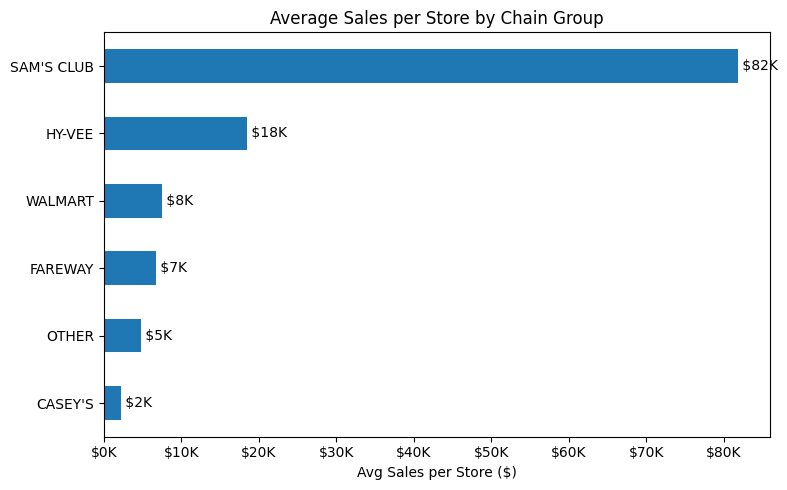

In [84]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_plot = df_perf.sort_values("avg_sales_per_store")

fig, ax = plt.subplots(figsize=(8, 5))

df_plot.set_index("chain_group")["avg_sales_per_store"].plot(
    kind="barh",
    ax=ax
)

ax.set_title("Average Sales per Store by Chain Group")
ax.set_xlabel("Avg Sales per Store ($)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1_000:,.0f}K")
)

# Labels
for i, v in enumerate(df_plot["avg_sales_per_store"]):
    ax.text(v, i, f" ${v/1_000:,.0f}K", va="center")

plt.tight_layout()
plt.show()

## Store Productivity: Average Sales per Store

## Key Insights: Store-Level Performance

**1. Store productivity varies significantly by retail format**  
Warehouse-style retailers (e.g., Sam’s Club) generate significantly higher sales per store due to bulk purchasing and larger basket sizes.

**2. Scale vs productivity tradeoff**  
HY-VEE leads in total sales due to its broad store footprint, while Sam’s Club leads in per-store productivity.

**3. Long tail is volume-driven, not efficiency-driven**  
The long tail contributes meaningful total sales but has significantly lower average sales per store.

**4. Cross-chain comparisons require context**  
Differences in performance are driven by underlying business models, not just execution.

## Analytical Considerations

**Revenue does not equal profitability**

While some chains show higher sales per store, this does not necessarily translate to higher profitability. Different retail formats operate under different cost structures:

- warehouse clubs → higher fixed and operating costs  
- convenience stores → lower cost structures but lower throughput  

A full performance evaluation would require cost and margin data, which is outside the scope of this analysis.

## Conclusion

The Iowa liquor sales market exhibits a hybrid structure:

- a dominant leading chain  
- a set of mid-sized competitors  
- a large and fragmented long tail  

Understanding both **scale (total sales)** and **efficiency (sales per store)** is critical for evaluating performance and identifying strategic opportunities.

This analysis demonstrates how combining data modeling (dbt), SQL, and Python-based exploration can uncover meaningful business insights from raw transactional data.